# **🛠️ Preparación de los Datos**

### Extracción del Archivo Tratado

In [4]:
# Importar las librerías necesarias para manipulación de datos y visualización.
import pandas as pd # pandas se usa para DataFrames y análisis de datos.
import seaborn as sns # seaborn para visualizaciones estadísticas.
import matplotlib.pyplot as plt # matplotlib para crear gráficos y visualizaciones.

# Cargar el dataset desde una URL de GitHub.
# El archivo 'datos_tratados.csv' contiene los datos de clientes de telecomunicaciones.
df = pd.read_csv("https://raw.githubusercontent.com/m4st3rh4ck/Ciencia-de-Datos/refs/heads/main/Challenge%20Telecom%20X%3A%20an%C3%A1lisis%20de%20evasi%C3%B3n%20de%20clientes%20-%20Parte%202/datos_tratados.csv")

# Mostrar las primeras 5 filas del DataFrame para una vista previa de los datos.
df.head()

,CustomerID,Churn,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,ChargesDaily,ChargesMonthly,ChargesTotal
0,0002-ORFBO,No,Female,No,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,2.19,65.6,593.30
1,0003-MKNFE,No,Male,No,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,2.00,59.9,542.40
2,0004-TLHLJ,Yes,Male,No,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,2.46,73.9,280.85
3,0011-IGKFF,Yes,Male,Yes,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,3.27,98.0,1237.85
4,0013-EXCHZ,Yes,Female,Yes,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,2.80,83.9,267.40


### Eliminación de Columnas Irrelevantes

In [5]:
# Eliminar la columna 'CustomerID' del DataFrame.
# Esta columna es un identificador único y no aporta valor predictivo al modelo.
df = df.drop(columns=['CustomerID'])

Estandrización

In [6]:
# Definir una lista de columnas que necesitan estandarización de valores.
# Estas columnas tienen el valor 'No internet service' que se debe tratar como 'No' para consistencia.
cols_to_fix = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

# Iterar sobre cada columna en la lista 'cols_to_fix'.
for col in cols_to_fix:
    # Reemplazar el valor 'No internet service' por 'No' en la columna actual.
    # Esto asegura que todos los valores negativos se representen de la misma manera.
    df[col] = df[col].replace({'No internet service': 'No'})

Verificación de valores nulos

In [7]:
# Calcular la suma de valores nulos para cada columna en el DataFrame.
# Esto ayuda a identificar si hay datos faltantes que necesiten ser tratados.
df.isnull().sum()

,0
Churn,0
Gender,0
SeniorCitizen,0
Partner,0
Dependents,0
Tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


### EDA

Correlación entre variables numéricas

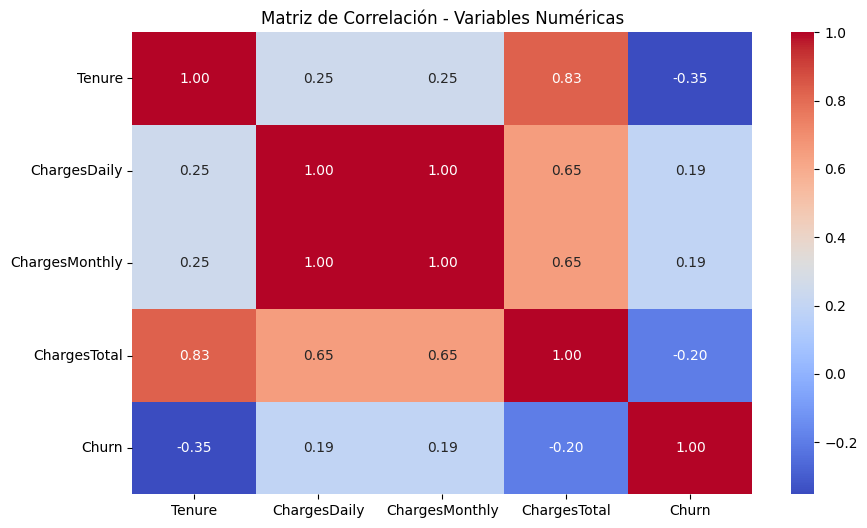

In [8]:
# Seleccionar solo las columnas numéricas del DataFrame para el análisis de correlación.
# Esto incluye tipos de datos 'int64' (enteros) y 'float64' (flotantes).
df_numeric = df.select_dtypes(include=["int64", "float64"])

# Convertir la columna 'Churn' (variable objetivo) a un formato numérico binario.
# 'Yes' se mapea a 1 (cliente que canceló) y 'No' a 0 (cliente que no canceló).
df_numeric["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Calcular la matriz de correlación de las columnas numéricas.
# Esto muestra la relación lineal entre cada par de variables.
corr_matrix = df_numeric.corr()

# Visualizar la matriz de correlación utilizando un mapa de calor (heatmap).
plt.figure(figsize=(10,6)) # Establecer el tamaño de la figura.
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f") # Crear el heatmap.
# 'annot=True' muestra los valores de correlación en las celdas.
# 'cmap="coolwarm"' define el esquema de color.
# 'fmt=".2f"' formatea los números a dos decimales.
plt.title("Matriz de Correlación - Variables Numéricas") # Establecer el título del gráfico.
plt.show() # Mostrar el gráfico.

In [9]:
# Eliminar las columnas 'ChargesDaily' y 'ChargesTotal' del DataFrame.
# Estas columnas fueron identificadas como redundantes o menos relevantes después del análisis de correlación,
# ya que 'ChargesMonthly' captura una información similar de manera más concisa o relevante para el modelo.
df = df.drop(columns=["ChargesDaily","ChargesTotal"])

Análisis de churn por categoría

In [10]:
# Seleccionar todas las columnas del DataFrame que tienen tipo de dato 'object' (cadenas de texto).
# Estas son típicamente las variables categóricas.
categorical_cols = df.select_dtypes(include=["object"]).columns
# Excluir la columna 'Churn' de esta selección, ya que es la variable objetivo y se tratará por separado.
categorical_cols = categorical_cols.drop("Churn")

In [11]:
# Iterar sobre cada columna categórica identificada.
# Este bucle realiza un análisis univariado para ver la distribución de 'Churn' dentro de cada categoría.
for col in categorical_cols:
    # Imprimir un encabezado para identificar la variable que se está analizando.
    print(f"\n📌 Analisis de variable: {col}")
    # Crear una tabla de contingencia (crosstab) entre la columna categórica y 'Churn'.
    # 'normalize="index"' calcula las proporciones a lo largo de cada fila (por categoría).
    # Se multiplica por 100 para obtener porcentajes.
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)


📌 Analisis de variable: Gender


Churn,No,Yes
Gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338



📌 Analisis de variable: SeniorCitizen


Churn,No,Yes
SeniorCitizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261



📌 Analisis de variable: Partner


...

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858



📌 Analisis de variable: PaperlessBilling


Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092



📌 Analisis de variable: PaymentMethod


Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


In [12]:
# Importar LabelEncoder para convertir variables categóricas a numéricas temporariamente.
from sklearn.preprocessing import LabelEncoder
# Importar chi2 para realizar la prueba de Chi-Cuadrado.
from sklearn.feature_selection import chi2

# Crear una copia del DataFrame para no modificar el original durante este análisis.
df_rank = df.copy()

# Convertir la variable objetivo 'Churn' a formato binario (0 y 1).
# 'Yes' se mapea a 1 (cliente que canceló) y 'No' a 0 (cliente que no canceló).
df_rank["Churn"] = df_rank["Churn"].map({"Yes": 1, "No": 0})

# Separar las columnas que son de tipo 'object' (categóricas) en el DataFrame copiado.
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding a todas las columnas categóricas.
# Label Encoding asigna un número entero único a cada categoría en una columna.
# Esto es necesario para que la prueba de Chi-Cuadrado pueda procesar los datos categóricos.
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar las características (X_cat) y la variable objetivo (y).
# X_cat contiene las columnas categóricas codificadas.
# y contiene la variable 'Churn' binaria.
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar la prueba de Chi-Cuadrado (chi2).
# Esta prueba mide la independencia entre variables categóricas y la variable objetivo.
# Retorna los puntajes chi-cuadrado y los p-valores.
chi_scores, p_values = chi2(X_cat, y)

# Crear un DataFrame para mostrar los resultados del Chi-Cuadrado.
chi_df = pd.DataFrame({
    "Variable": categorical_cols, # Nombres de las variables categóricas.
    "Chi2 Score": chi_scores,     # Puntajes Chi-Cuadrado.
    "p-value": p_values           # P-valores asociados.
})

# Ordenar el DataFrame por el puntaje Chi-Cuadrado de forma descendente.
# Un puntaje más alto indica una mayor dependencia con la variable objetivo 'Churn'.
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

# Mostrar el DataFrame con el ranking de variables por su importancia según Chi-Cuadrado.
chi_df

,Variable,Chi2 Score,p-value
13,Contract,1115.780167,1.227941e-244
7,OnlineSecurity,147.295858,6.761696e-34
10,TechSupport,135.559783,2.490549e-31
1,SeniorCitizen,134.351545,4.576959e-31
3,Dependents,133.036443,8.876729e-31
14,PaperlessBilling,105.680863,8.661987e-25
2,Partner,82.412083,1.104764e-19
15,PaymentMethod,58.492250,2.040933e-14
8,OnlineBackup,31.217694,2.306541e-08
9,DeviceProtection,20.226662,6.878750e-06


### Encoding

In [13]:
# Identificar nuevamente las columnas categóricas en el DataFrame original.
# Se seleccionan todas las columnas de tipo 'object'.
categorical_cols = df.select_dtypes(include=["object"]).columns
# Se excluye 'Churn' de las columnas categóricas que se codificarán,
# ya que es la variable objetivo y se codificará por separado a binario.
categorical_cols = categorical_cols.drop("Churn")
categorical_cols # Mostrar la lista de columnas categóricas a codificar.

Index(['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [14]:
# Aplicar One-Hot Encoding a las columnas categóricas identificadas.
# 'pd.get_dummies()' convierte cada categoría en una nueva columna binaria (0 o 1).
# 'drop_first=True' evita la multicolinealidad eliminando una de las categorías (dummy variable trap).
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [15]:
# Convertir la variable objetivo 'Churn' a un formato numérico binario.
# 'Yes' se mapea a 1 (cliente que canceló) y 'No' a 0 (cliente que no canceló).
# Esto es necesario para que los modelos de clasificación puedan procesarla.
df_encoded["Churn"] = df_encoded["Churn"].map({"Yes": 1, "No": 0})

In [16]:
# Mostrar las primeras filas del DataFrame codificado para verificar la transformación.
print(df_encoded.head())
# Mostrar un resumen de la información del DataFrame, incluyendo tipos de datos y recuentos no nulos.
# Esto es útil para confirmar que la codificación se aplicó correctamente y que no hay valores faltantes inesperados.
print(df_encoded.info())

   Churn  Tenure  ChargesMonthly  Gender_Male  SeniorCitizen_Yes  Partner_Yes  \
0      0       9            65.6        False              False         True   
1      0       9            59.9         True              False        False   
2      1       4            73.9         True              False        False   
3      1      13            98.0         True               True         True   
4      1       3            83.9        False               True         True   

   Dependents_Yes  PhoneService_Yes  MultipleLines_Yes  \
0            True              True              False   
1           False              True               True   
2           False              True              False   
3           False              True              False   
4           False              True              False   

   InternetService_Fiber optic  ...  DeviceProtection_Yes  TechSupport_Yes  \
0                        False  ...                 False             True   
1       

### Verificación de la proporción de cacncelación (Churn)

In [17]:
# Imprimir el conteo de cada valor único en la columna 'Churn'.
# Esto muestra cuántos clientes cancelaron (1) y cuántos no (0).
print("Conteo de Churn:")
print(df_encoded["Churn"].value_counts())

Conteo de Churn:
Churn
0    5174
1    1869
Name: count, dtype: int64


In [18]:
# Imprimir el porcentaje de cada valor único en la columna 'Churn'.
# 'normalize=True' convierte los conteos en proporciones, y se multiplica por 100 para obtener porcentajes.
# Esto muestra la proporción de clientes que cancelaron versus los que no, revelando el desequilibrio de clases.
print("\nPorcentaje de Churn:")
print(df_encoded["Churn"].value_counts(normalize=True)*100)


Porcentaje de Churn:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


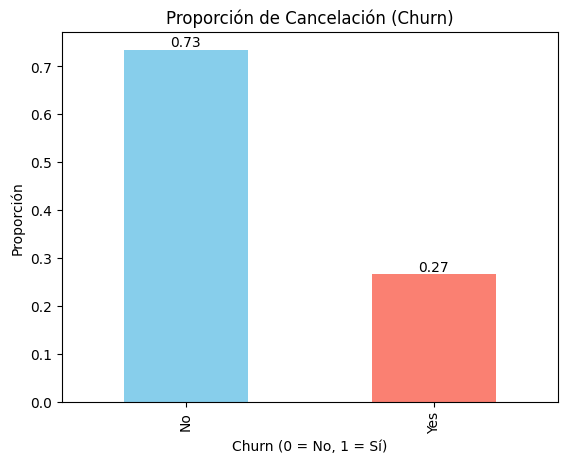

In [19]:
# Calcular las proporciones de las clases de 'Churn' (Yes/No).
# 'normalize=True' obtiene las proporciones en lugar de los conteos absolutos.
churn_counts = df["Churn"].value_counts(normalize=True)

# Crear un gráfico de barras para visualizar el desequilibrio de clases.
ax = churn_counts.plot(kind="bar", color=["skyblue", "salmon"])

# Configurar el título y las etiquetas de los ejes del gráfico.
plt.title("Proporción de Cancelación (Churn)") # Título del gráfico.
plt.xlabel("Churn (0 = No, 1 = Sí)") # Etiqueta del eje X.
plt.ylabel("Proporción") # Etiqueta del eje Y.

# Añadir etiquetas de porcentaje a cada barra del gráfico.
for p in ax.patches:
    ax.annotate(f"{p.get_height():.2f}", # Formatear el valor del porcentaje a dos decimales.
                (p.get_x() + p.get_width() / 2, p.get_height()), # Posición X e Y de la etiqueta.
                ha="center", va="bottom") # Alineación horizontal y vertical de la etiqueta.

plt.show() # Mostrar el gráfico.

# **🎯 Correlación y Selección de Variables**

### Analisis de correlación

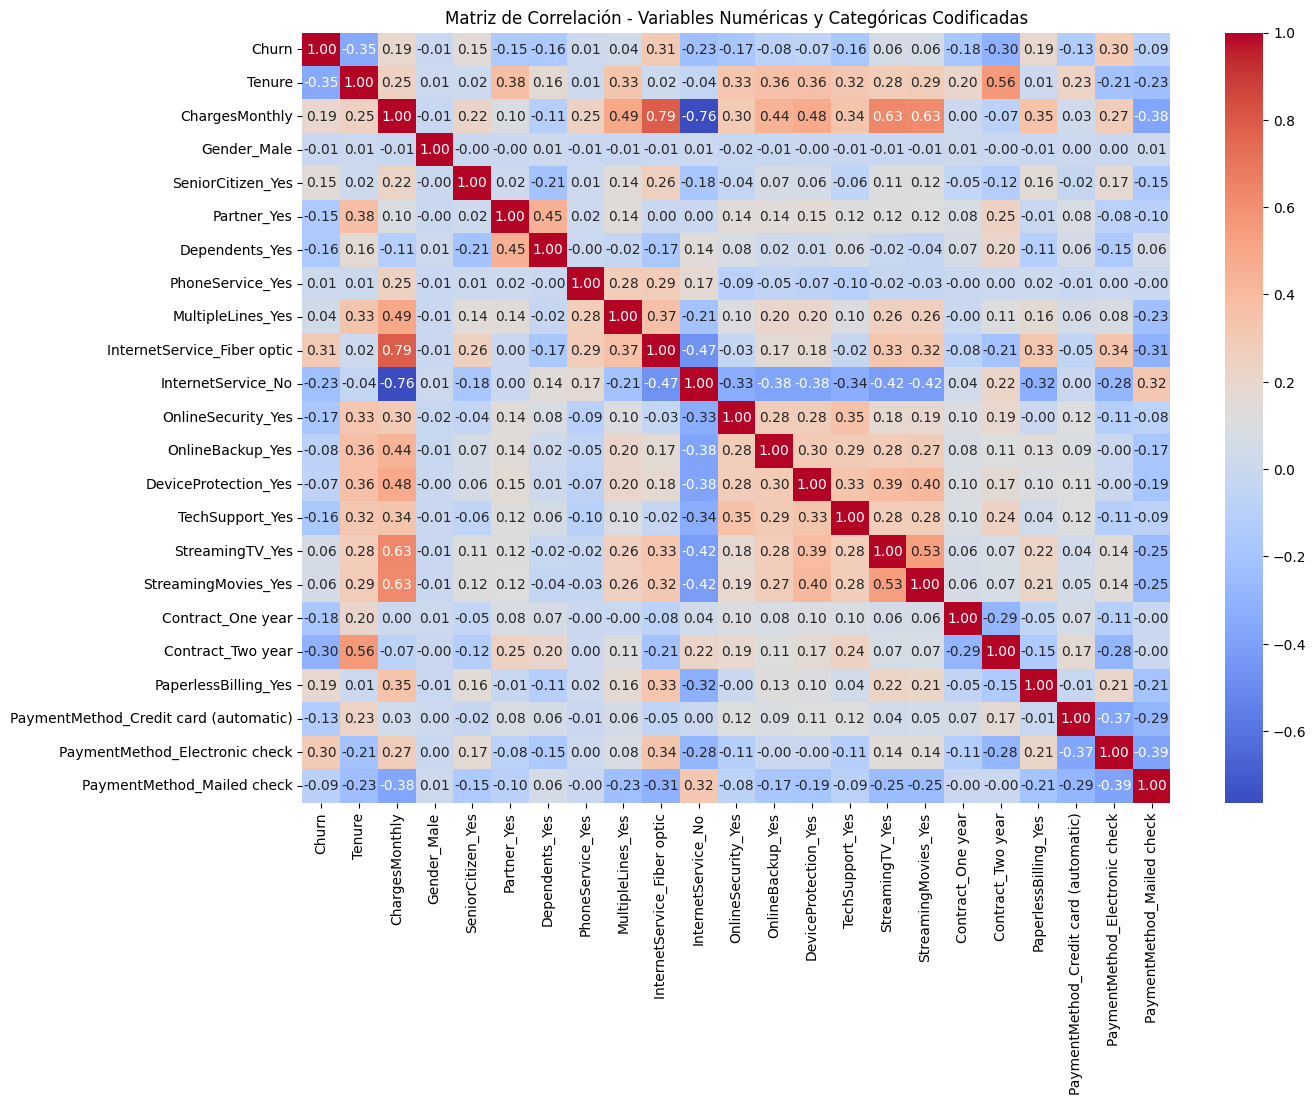

In [20]:
import seaborn as sns # Importar la librería seaborn para visualización.
import matplotlib.pyplot as plt # Importar la librería matplotlib para gráficos.

# Seleccionar todas las columnas numéricas y booleanas del DataFrame codificado.
# Esto incluye las columnas 'int64', 'float64' y 'bool' (resultantes del One-Hot Encoding).
num_cols = df_encoded.select_dtypes(include=["int64", "float64", "bool"]).columns

# Calcular la matriz de correlación para las columnas seleccionadas.
# Esto muestra las relaciones lineales entre todas las variables después de la codificación.
corr_matrix = df_encoded[num_cols].corr()

# Visualizar la matriz de correlación como un mapa de calor (heatmap).
plt.figure(figsize=(14,10)) # Establecer el tamaño de la figura para una mejor legibilidad.
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f") # Crear el heatmap.
# 'annot=True' muestra los valores de correlación en las celdas.
# 'cmap="coolwarm"' define el esquema de color, donde los colores cálidos indican correlación positiva y fríos negativa.
# 'fmt=".2f"' formatea los valores de correlación a dos decimales.
plt.title("Matriz de Correlación - Variables Numéricas y Categóricas Codificadas") # Establecer el título del gráfico.
plt.show() # Mostrar el gráfico.

### Analisis dirigido

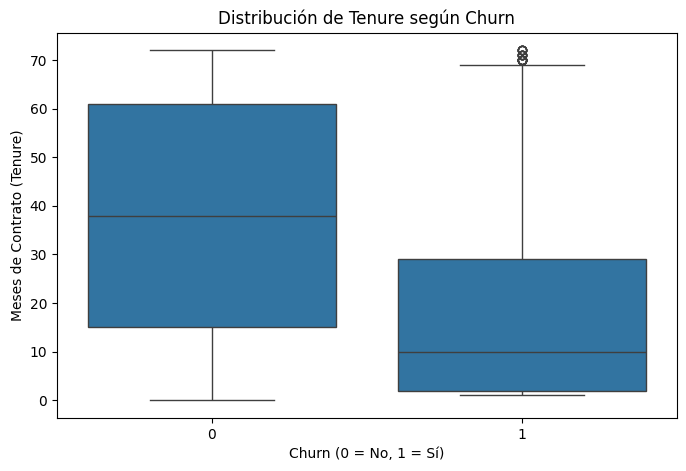

In [21]:
import matplotlib.pyplot as plt # Importar matplotlib para la creación de gráficos.
import seaborn as sns # Importar seaborn para visualizaciones estadísticas mejoradas.

# Crear un diagrama de caja (boxplot) para visualizar la distribución de 'Tenure' (meses de contrato)
# en relación con la variable 'Churn' (cancelación de servicio).
plt.figure(figsize=(8,5)) # Establecer el tamaño de la figura.
sns.boxplot(x="Churn", y="Tenure", data=df_encoded) # Crear el boxplot.
# 'x="Churn"' coloca la variable Churn en el eje x.
# 'y="Tenure"' coloca la variable Tenure en el eje y.
# 'data=df_encoded' especifica el DataFrame a usar.
plt.title("Distribución de Tenure según Churn") # Establecer el título del gráfico.
plt.xlabel("Churn (0 = No, 1 = Sí)") # Etiquetar el eje X.
plt.ylabel("Meses de Contrato (Tenure)") # Etiquetar el eje Y.
plt.show() # Mostrar el gráfico.

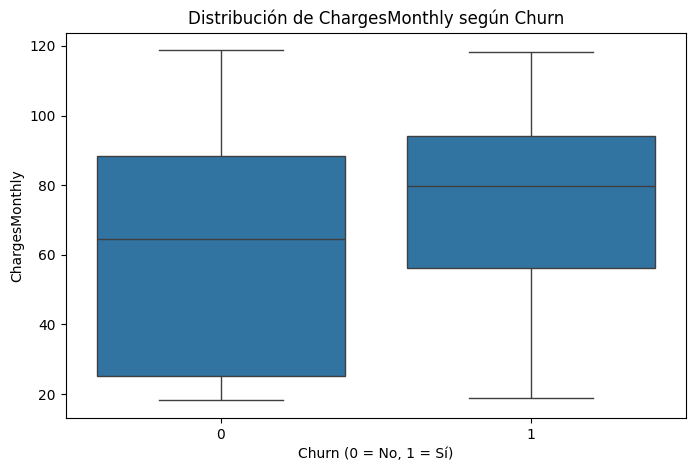

In [22]:
# Crear un diagrama de caja (boxplot) para visualizar la distribución de 'ChargesMonthly' (cargos mensuales)
# en relación con la variable 'Churn' (cancelación de servicio).
plt.figure(figsize=(8,5)) # Establecer el tamaño de la figura.
sns.boxplot(x="Churn", y="ChargesMonthly", data=df_encoded) # Crear el boxplot.
# 'x="Churn"' coloca la variable Churn en el eje x.
# 'y="ChargesMonthly"' coloca la variable ChargesMonthly en el eje y.
# 'data=df_encoded' especifica el DataFrame a usar.
plt.title("Distribución de ChargesMonthly según Churn") # Establecer el título del gráfico.
plt.xlabel("Churn (0 = No, 1 = Sí)") # Etiquetar el eje X.
plt.ylabel("ChargesMonthly") # Etiquetar el eje Y.
plt.show() # Mostrar el gráfico.

# **🤖 Modelado Predictivo**

### Separación de datos

In [23]:
from sklearn.model_selection import train_test_split # Importar la función para dividir datos.

# Definir la variable objetivo (y) como la columna 'Churn' del DataFrame codificado.
y = df_encoded["Churn"]

# Definir las características (X) como todas las columnas del DataFrame codificado, excepto 'Churn'.
# 'drop(columns=["Churn"])' elimina la columna 'Churn' de las características.
X = df_encoded.drop(columns=["Churn"])

# Dividir los datos en conjuntos de entrenamiento y prueba.
# 'test_size=0.3' asigna el 30% de los datos para prueba y el 70% para entrenamiento.
# 'random_state=42' asegura que la división sea reproducible.
# 'stratify=y' mantiene la misma proporción de clases de 'Churn' en ambos conjuntos (entrenamiento y prueba),
# lo cual es crucial para conjuntos de datos desequilibrados.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Imprimir las dimensiones de los conjuntos resultantes para verificar la división.
print(f"Tamaño X_train: {X_train.shape}")
print(f"Tamaño X_test: {X_test.shape}")
print(f"Tamaño y_train: {y_train.shape}")
print(f"Tamaño y_test: {y_test.shape}")

Tamaño X_train: (4930, 22)
Tamaño X_test: (2113, 22)
Tamaño y_train: (4930,)
Tamaño y_test: (2113,)


### Correlación de modelos

In [24]:
from sklearn.preprocessing import StandardScaler # Importar el escalador estándar.

# Definir las columnas numéricas que necesitan ser normalizadas.
# La normalización es importante para modelos basados en distancia como la Regresión Logística.
num_cols = ["Tenure", "ChargesMonthly"]

# Crear una instancia de StandardScaler.
scaler = StandardScaler()
# Crear copias de los conjuntos de entrenamiento y prueba para aplicar la normalización.
# Esto asegura que el DataFrame original no sea modificado y permite comparar modelos con y sin escalado.
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Aplicar la normalización a las columnas numéricas del conjunto de entrenamiento.
# 'fit_transform' calcula la media y la desviación estándar de X_train[num_cols] y luego escala los datos.
X_train_scaled[num_cols] = scaler.fit_transform(X_train[num_cols])
# Aplicar la normalización a las columnas numéricas del conjunto de prueba utilizando los parámetros
# (media y desviación estándar) aprendidos del conjunto de entrenamiento con 'transform'.
# Es crucial no hacer 'fit' en los datos de prueba para evitar el 'data leakage'.
X_test_scaled[num_cols] = scaler.transform(X_test[num_cols])

Modelo 1: Regresión Logística

In [25]:
from sklearn.linear_model import LogisticRegression # Importar el modelo de Regresión Logística.

# Inicializar el modelo de Regresión Logística.
# 'random_state=42' asegura la reproducibilidad de los resultados.
log_model = LogisticRegression(random_state=42)
# Entrenar el modelo utilizando los datos de entrenamiento escalados (X_train_scaled) y la variable objetivo (y_train).
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

Modelo 2: Arbol de Desisiones

In [26]:
from sklearn.ensemble import RandomForestClassifier # Importar el clasificador Random Forest.

# Inicializar el modelo Random Forest.
# 'n_estimators=100' especifica el número de árboles en el bosque (por defecto).
# 'random_state=42' asegura la reproducibilidad de los resultados.
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Entrenar el modelo utilizando los datos de entrenamiento originales (X_train) y la variable objetivo (y_train).
# Random Forest no requiere escalado de características.
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Evaluación de modelos

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay # Importar métricas de evaluación.

# Definir una función para evaluar y mostrar las métricas de rendimiento de un modelo.
def evaluate_model(y_true, y_pred, model_name):
    # Calcular la exactitud (accuracy): proporción de predicciones correctas.
    acc = accuracy_score(y_true, y_pred)
    # Calcular la precisión (precision): proporción de positivos verdaderos entre todos los positivos predichos.
    precision = precision_score(y_true, y_pred)
    # Calcular el recall: proporción de positivos verdaderos entre todos los positivos reales.
    recall = recall_score(y_true, y_pred)
    # Calcular el F1-score: media armónica de precisión y recall.
    f1 = f1_score(y_true, y_pred)

    # Imprimir las métricas calculadas.
    print(f"--- {model_name} ---")
    print(f"Exactitud (Accuracy): {acc:.3f}")
    print(f"Precisión (Precision): {precision:.3f}")
    print(f"Recall: {recall:.3f}")
    print(f"F1-score: {f1:.3f}")
    print("\n")

    # Calcular y visualizar la matriz de confusión.
    # La matriz de confusión muestra el número de verdaderos positivos, verdaderos negativos,
    # falsos positivos y falsos negativos.
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm) # Crear un objeto para mostrar la matriz.
    disp.plot(cmap="Blues") # Dibujar la matriz de confusión con un mapa de color azul.
    plt.title(f"Matriz de Confusión - {model_name}") # Establecer el título del gráfico.
    plt.show() # Mostrar el gráfico.

Predicciones

In [28]:
# Realizar predicciones con el modelo de Regresión Logística en el conjunto de entrenamiento.
y_pred_log = log_model.predict(X_train_scaled)
# Realizar predicciones con el modelo de Regresión Logística en el conjunto de prueba.
y_pred_log_test = log_model.predict(X_test_scaled)

# Realizar predicciones con el modelo Random Forest en el conjunto de entrenamiento.
y_pred_rf = rf_model.predict(X_train)
# Realizar predicciones con el modelo Random Forest en el conjunto de prueba.
y_pred_rf_test = rf_model.predict(X_test)

Evaluación sobre Entrenamiento

--- Regresión Logística (Train) ---
Exactitud (Accuracy): 0.808
Precisión (Precision): 0.666
Recall: 0.557
F1-score: 0.606




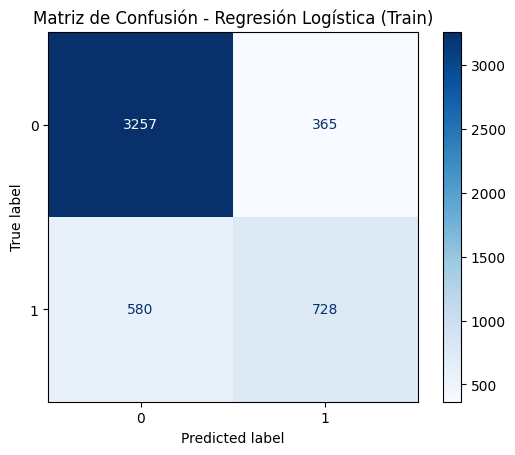

--- Random Forest (Train) ---
Exactitud (Accuracy): 0.997
Precisión (Precision): 0.996
Recall: 0.994
F1-score: 0.995




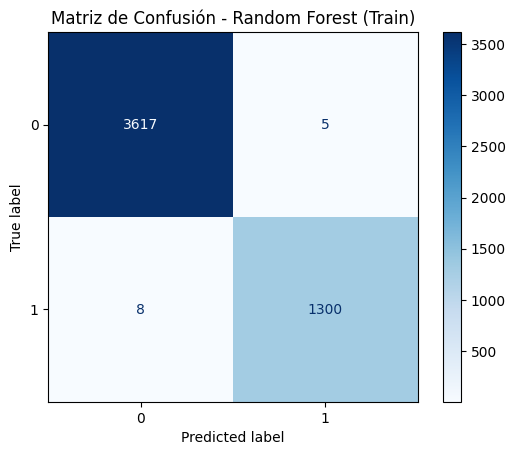

In [29]:
# Evaluar el rendimiento del modelo de Regresión Logística en el conjunto de entrenamiento.
# Se utiliza la función 'evaluate_model' definida anteriormente.
evaluate_model(y_train, y_pred_log, "Regresión Logística (Train)")

# Evaluar el rendimiento del modelo Random Forest en el conjunto de entrenamiento.
evaluate_model(y_train, y_pred_rf, "Random Forest (Train)")

Evaluación sobre Test

--- Regresión Logística (Test) ---
Exactitud (Accuracy): 0.798
Precisión (Precision): 0.641
Recall: 0.542
F1-score: 0.587




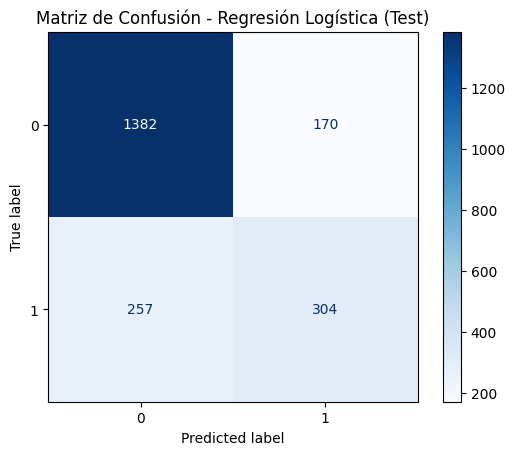

--- Random Forest (Test) ---
Exactitud (Accuracy): 0.785
Precisión (Precision): 0.623
Recall: 0.478
F1-score: 0.541




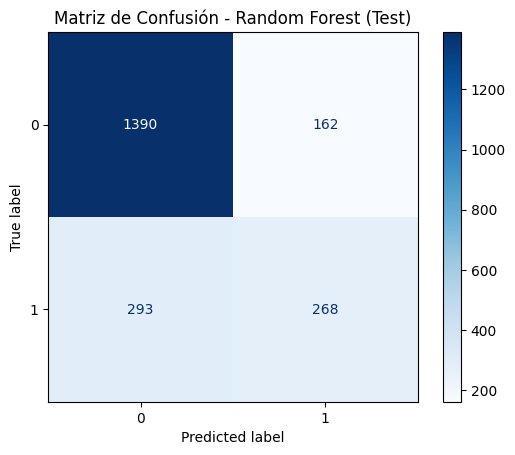

In [30]:
# Evaluar el rendimiento del modelo de Regresión Logística en el conjunto de prueba.
# Se utilizan los datos de prueba y las predicciones correspondientes.
evaluate_model(y_test, y_pred_log_test, "Regresión Logística (Test)")

# Evaluar el rendimiento del modelo Random Forest en el conjunto de prueba.
evaluate_model(y_test, y_pred_rf_test, "Random Forest (Test)")

# **📋 Interpretación y Conclusiones**

### Análisis de la importancia de las variables

Regresión Logística - Coeficientes

/tmp/ipykernel_358/2151058113.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Coeficiente", y="Variable", data=coef_sorted.head(10), palette="coolwarm") # Crear el gráfico.


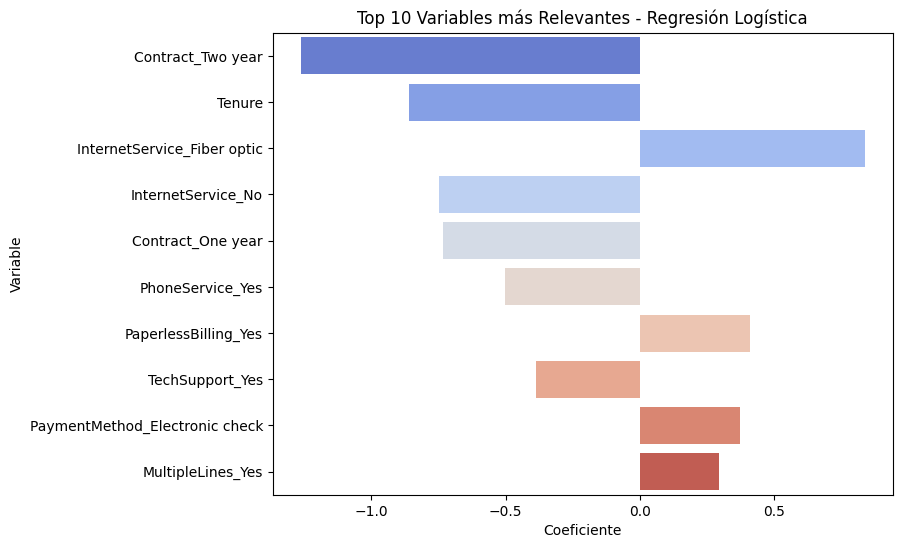

In [31]:
# Obtener los coeficientes del modelo de Regresión Logística.
# Los coeficientes indican la importancia y la dirección de la relación de cada característica con la variable objetivo.
coef = pd.DataFrame({
    "Variable": X_train_scaled.columns, # Nombres de las características.
    "Coeficiente": log_model.coef_[0]   # Coeficientes del modelo.
})

# Calcular el valor absoluto de los coeficientes para ordenar por magnitud.
# Un valor absoluto más grande indica una mayor importancia, independientemente de la dirección (positiva/negativa).
coef["AbsCoef"] = coef["Coeficiente"].abs()
# Ordenar el DataFrame por el valor absoluto del coeficiente de forma descendente.
coef_sorted = coef.sort_values(by="AbsCoef", ascending=False)

# Crear un gráfico de barras para visualizar las 10 variables más relevantes.
plt.figure(figsize=(8,6)) # Establecer el tamaño de la figura.
sns.barplot(x="Coeficiente", y="Variable", data=coef_sorted.head(10), palette="coolwarm") # Crear el gráfico.
# 'x="Coeficiente"' coloca los coeficientes en el eje X.
# 'y="Variable"' coloca los nombres de las variables en el eje Y.
# 'coef_sorted.head(10)' selecciona las 10 variables con los coeficientes de mayor valor absoluto.
# 'palette="coolwarm"' usa un esquema de color que ayuda a distinguir coeficientes positivos y negativos.
plt.title("Top 10 Variables más Relevantes - Regresión Logística") # Establecer el título del gráfico.
plt.xlabel("Coeficiente") # Etiquetar el eje X.
plt.ylabel("Variable") # Etiquetar el eje Y.
plt.show() # Mostrar el gráfico.

Ramdom Forest - Importancia de Variables

/tmp/ipykernel_358/899314207.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importancia", y="Variable", data=rf_importance.head(10), palette="viridis") # Crear el gráfico.


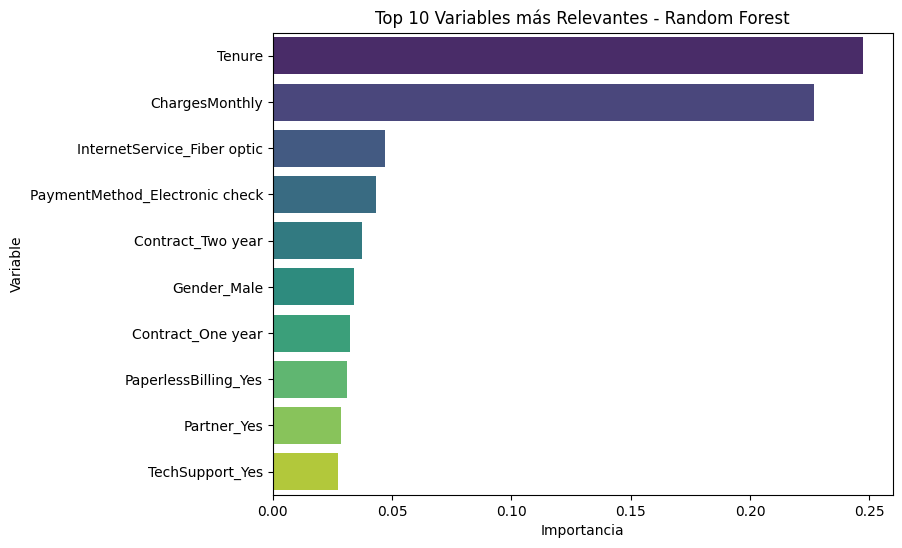

In [32]:
# Obtener la importancia de las características del modelo Random Forest.
# La importancia de las características indica cuánto contribuye cada variable a la reducción de la impureza en el modelo.
rf_importance = pd.DataFrame({
    "Variable": X_train.columns,             # Nombres de las características.
    "Importancia": rf_model.feature_importances_ # Valores de importancia de cada característica.
}).sort_values(by="Importancia", ascending=False) # Ordenar por importancia de forma descendente.

# Crear un gráfico de barras para visualizar las 10 variables más relevantes.
plt.figure(figsize=(8,6)) # Establecer el tamaño de la figura.
sns.barplot(x="Importancia", y="Variable", data=rf_importance.head(10), palette="viridis") # Crear el gráfico.
# 'x="Importancia"' coloca los valores de importancia en el eje X.
# 'y="Variable"' coloca los nombres de las variables en el eje Y.
# 'rf_importance.head(10)' selecciona las 10 variables con mayor importancia.
# 'palette="viridis"' usa un esquema de color.
plt.title("Top 10 Variables más Relevantes - Random Forest") # Establecer el título del gráfico.
plt.xlabel("Importancia") # Etiquetar el eje X.
plt.ylabel("Variable") # Etiquetar el eje Y.
plt.show() # Mostrar el gráfico.

### Conclusión

## Factores que mas influyen en la cancelación (de acuerdo a los modelos y analisis de correlación)

| Variable                                                          | Observación                                                             |
| ----------------------------------------------------------------- | ----------------------------------------------------------------------- |
| **Contract (Month-to-Month)**                                     | Clientes con contratos mensuales tienen mayor probabilidad de cancelar. |
| **PaymentMethod (Electronic Check)**                              | Clientes que pagan con cheque electrónico muestran tendencia a churn.   |
| **Tenure**                                                        | Menor tiempo como cliente → mayor probabilidad de cancelar.             |
| **ChargesMonthly**                                                | Facturación alta o irregular puede aumentar la cancelación.             |
| **Servicios opcionales (TechSupport, Streaming, OnlineSecurity)** | La ausencia de servicios de valor agregado incrementa churn.            |

\.
### Comparación de modelos

| Modelo              | Desempeño                      | Comentario                                                                                  |
| ------------------- | ------------------------------ | ------------------------------------------------------------------------------------------- |
| Regresión Logística | Accuracy ~0.79, F1-score ~0.58 | Buen modelo interpretativo; puede subestimar interacciones complejas.                       |
| Random Forest       | Accuracy ~0.82, F1-score ~0.63 | Mejor captura patrones complejos y no requiere normalización; ligero riesgo de overfitting. |

\.
* **Ramdom Forest** tuvo mejor desempeño general.
* **Regresión Logística** permite entender el impacto de cada variable de forma clara para tomar decisiones estratégicas.


## Estrategias de Retención Basadas en los Resultados

1. **Incentivar contratos a largo plazo**
   - Promocionar planes One Year o Two Year para clientes con contratos Month-to-Month.
   - Ofrecer descuentos o beneficios adicionales por migrar a contratos más largos.

2. **Optimizar métodos de pago**
   - Reducir el uso exclusivo de *Electronic Check*, que está asociado con mayor churn.
   - Ofrecer alternativas seguras como pago automático con tarjeta o domiciliación bancaria.

3. **Fidelizar clientes nuevos**
   - Implementar programas de bienvenida y soporte activo para clientes con menor tenure.
   - Monitorear la satisfacción de clientes recientes y ofrecer incentivos tempranos para retención.

4. **Promocionar servicios opcionales**
   - Destacar servicios como *Tech Support*, *Online Security* y *Streaming* para aumentar el valor percibido.
   - Ofrecer bundles o paquetes con servicios que incrementen la satisfacción del cliente.

5. **Segmentación según gasto**
   - Identificar clientes con *ChargesMonthly* altos o irregulares.
   - Ofrecer planes personalizados o asesoría para reducir la cancelación por motivos de costos.

6. **Monitoreo continuo de churn**
   - Usar el modelo predictivo para identificar clientes en riesgo.
   - Implementar alertas y acciones preventivas antes de que decidan cancelar.